# Project 2 - Part 2: Extended Modelling

In [156]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

### **Birth/death rates included**

Deterministic model (ODEs):

\begin{align*}
\frac{dS}{dt} &= \Lambda - \mu S -\frac{\beta}{N}IS, \\
\frac{dI}{dt} &= \frac{\beta}{N}IS - \gamma I - \mu I - \alpha I, \\
\frac{dR}{dt} &= \gamma I - \mu R.
\end{align*}

Fatality rates from:
- Ebola: https://www.who.int/news-room/fact-sheets/detail/ebola-disease
- COVID-19 (Omicron): https://pmc.ncbi.nlm.nih.gov/articles/PMC11153312/
- Influenza: https://www.ecdc.europa.eu/en/seasonal-influenza 

General death rate based on: https://www.ssi.dk/sygdomme-beredskab-og-forskning/sygdomsovervaagning/d/overvaagning-af-doedelighed --> 20 per 100.000 people per week.

In [157]:
## General death rate

print(f"Death rate mu = {19 / 100000 / 7}")

Death rate mu = 2.7142857142857144e-05


In [158]:
#%% Plotting parameters
plt.rcParams.update({
    "font.size": 14,        # default text
    "axes.titlesize": 20,   # subplot titles
    "axes.labelsize": 18,   # axis labels
    "xtick.labelsize": 14,  # x tick labels
    "ytick.labelsize": 14,  # y tick labels
    "legend.fontsize": 18
})

In [159]:
#%% Functions

# SIR ODE system (with birth and death rates included)
def sir_ode_bd(t, y, beta, gamma, mu, alpha):
    S, I, R = y
    N_current = S + I + R
    Lambda = mu * N_current

    dSdt = Lambda - mu * S - beta/N_current * I * S
    dIdt = beta/N_current * I * S - gamma * I - mu * I - alpha * I 
    dRdt = gamma * I - mu * R

    return (dSdt, dIdt, dRdt)


# CTMC SIR (with birth and death rates included) simulation function
def simulate_sir_ctmc_bd(N, beta, gamma, mu, alpha, I0=1, R0=0, t_max=100, seed=None):
    
    # Set seed for reproducibility (if seed is not None)
    if seed is not None:
        np.random.seed(seed)

    # Initial condition
    S = N - I0 - R0
    I = I0
    R = R0
    t = 0

    # Initialize lists to save results
    times = [t]
    S_values = [S]
    I_values = [I]
    R_values = [R]

    # Run simulation until time limit 
    while t < t_max:

        # Update population size
        N_current = S + I + R 

        # Compute event rates
        S_rate = mu * N_current # rate of birth = rate of generating susceptibles 
        I_rate = beta * S * I / N_current # rate of getting infected 
        R_rate = gamma * I # rate of recovering
        death_S_rate = mu * S # rate of susceptibles dying
        death_I_rate = mu * I + alpha * I # rate of infected dying
        death_R_rate = mu * R # rate of recovered dying
        rates = np.array([S_rate, I_rate, R_rate, death_S_rate, death_I_rate, death_R_rate]) # list of all rates
        total_rate = rates.sum() # total rate of leaving the current state

        # If no people move between compartments, break
        if total_rate == 0:
            break

        # Time to next event
        dt = np.random.exponential(scale=1 / total_rate) # Exponentially distributed
        t += dt

        # Choose event type
        E = np.random.choice(len(rates), p=rates/total_rate)

        if E == 0:
            # Birth: new susceptible
            S += 1
        elif E == 1:
            # Infection: S -> I
            S -= 1
            I += 1
        elif E == 2:
            # Recovery: I -> R
            I -= 1
            R += 1
        elif E == 3:
            # Death of susceptible
            S -= 1
        elif E == 4:
            # Death of infected
            I -= 1
        elif E == 5:
            # Death of recovered
            R -= 1

        # Save results
        times.append(t)
        S_values.append(S)
        I_values.append(I)
        R_values.append(R)

    return np.array(times), np.array(S_values), np.array(I_values), np.array(R_values)

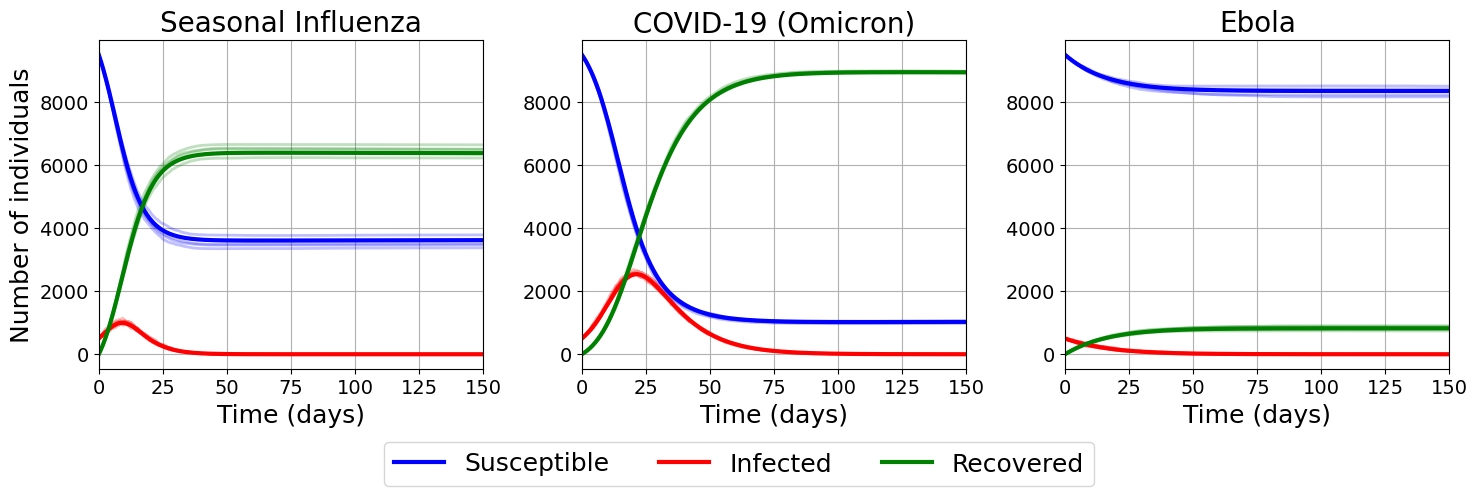

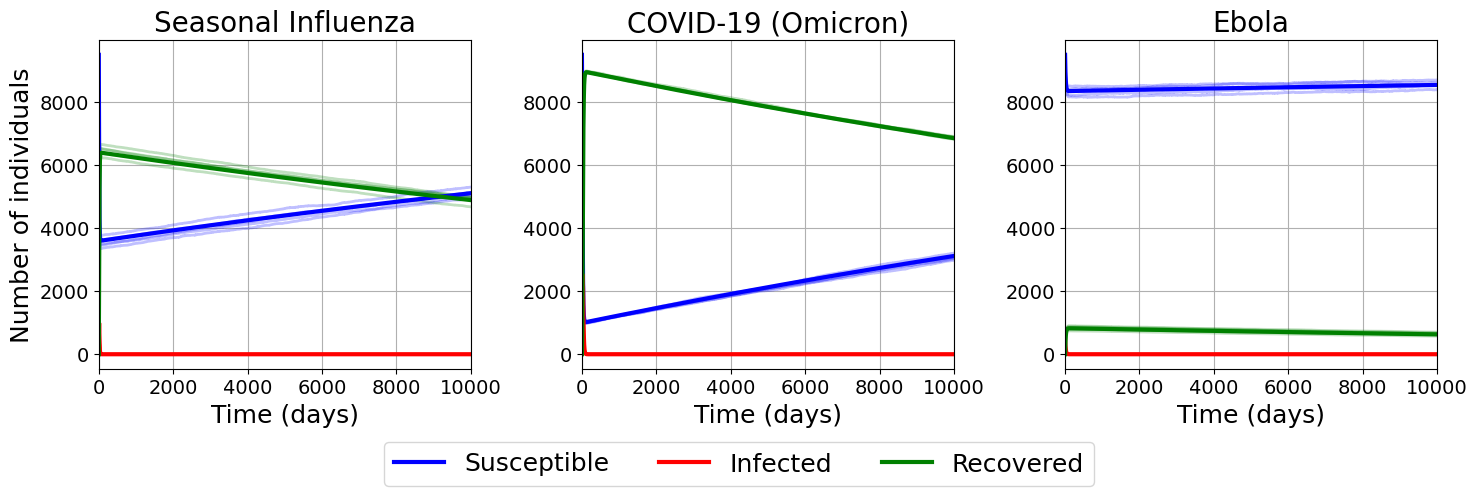

In [160]:
#%% Run simulation

# Parameters
n_reps = 5 # Number of repetitions of the simulation (for each N)
N = 10000 # Population size 
I0 = 0.05*N # Initial number of infected
R0 = 0 # Initial number of recovered
S0 = N - I0 - R0 # Initial number of susceptible 
diseases = ["Seasonal Influenza", "COVID-19 (Omicron)", "Ebola"]
betas = np.array([0.5, 0.25, 0.15]) # beta values for each disease
gammas = np.array([0.33, 0.1, 0.1]) # gamma values for each disease
mu = 2.7e-05 # general death rate
fatality_prob = np.array([0.0001, 0.003, 0.5]) # mortality probabilities for each disease
alphas = (fatality_prob / (1 - fatality_prob)) * (gammas + mu) # death rates caused by disease for each disease
t_start = 0 # start of time
t_ends = [150, 10000] # time limits

# Run simulations
for t_end in t_ends:

    # Time interval
    t_vals = np.linspace(t_start, t_end, 1000)

    # Setup plot
    fig, ax = plt.subplots(1,len(diseases), figsize=(15,5))

    # Run experiment for each disease
    for i, disease in enumerate(diseases):

        beta = betas[i]
        gamma = gammas[i]
        alpha = alphas[i]

        #%% Deterministic ODE solution
        # Solve ODE system using solve_ivp (used to "Solve an initial value problem for a system of ODEs")
        sol = solve_ivp(fun=sir_ode_bd, t_span=(t_start, t_end), y0=[S0, I0, R0], args=[beta, gamma, mu, alpha], t_eval=t_vals)
        # Extract solution
        S_det, I_det, R_det = sol.y

        #%% Stochastic CTMC simulations
        times_all = []
        S_all = []
        I_all = []
        R_all = []

        # Run simulations
        for j in range(n_reps):
            times, S, I, R = simulate_sir_ctmc_bd(N, beta, gamma, mu, alpha, I0, R0, t_end, seed=j)
            times_all.append(times)
            S_all.append(S)
            I_all.append(I)
            R_all.append(R)

        #%% Plot
        if len(diseases)==1:
            axis = ax
        else:
            axis = ax[i]

        # CTMC realizations
        for times, S, I, R in zip(times_all, S_all, I_all, R_all):
            axis.plot(times, S, color="b", alpha=0.25, linewidth=2)
            axis.plot(times, I, color="r", alpha=0.25, linewidth=2)
            axis.plot(times, R, color="g", alpha=0.25, linewidth=2)

        # Deterministic ODE
        lineS, = axis.plot(sol.t, S_det, color="b", linewidth=3, label="Susceptible")
        lineI, = axis.plot(sol.t, I_det, color="r", linewidth=3, label="Infected")
        lineR, = axis.plot(sol.t, R_det, color="g", linewidth=3, label="Recovered")

        axis.set_xlim(0, t_end)
        axis.set_xlabel("Time (days)")
        if i==0:
            axis.set_ylabel("Number of individuals")
        axis.set_title(f"{disease}")
        axis.grid()

    # Add shared legend
    fig.legend(
        [lineS, lineI, lineR],
        ["Susceptible", "Infected", "Recovered"],
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.02)
    )
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

### **Vaccination**